# Workalong: Finding Earthquakes in California

This workalong uses `geopandas` to find earthquakes within California.  It builds from the [lesson 05 warmup](../05_multidimensional_arrays_also_plotting/05_warmup_SOLUTION.ipynb), in which we used pandas to find earthquakes from a USGS dataset.  We'll use a similar approach to initially load the same dataset.

<iframe id="kaltura_player" src='https://cdnapisec.kaltura.com/p/1751071/embedPlaykitJs/uiconf_id/55382703?iframeembed=true&amp;entry_id=1_1dpg4dg0&amp;config%5Bprovider%5D=%7B%22widgetId%22%3A%221_vmma05ed%22%7D&amp;config%5Bplayback%5D=%7B%22startTime%22%3A0%7D'  style="width: 528px;height: 297px;border: 0;" allowfullscreen webkitallowfullscreen mozAllowFullScreen allow="autoplay *; fullscreen *; encrypted-media *" sandbox="allow-downloads allow-forms allow-same-origin allow-scripts allow-top-navigation allow-pointer-lock allow-popups allow-modals allow-orientation-lock allow-popups-to-escape-sandbox allow-presentation allow-top-navigation-by-user-activation" title="EAS-G 690 - Lesson 13 part 1"></iframe>

*Use [this link](https://iu.mediaspace.kaltura.com/media/t/1_1dpg4dg0/388761952) if you have issues viewing the above embeded video.*

In [24]:
""" Import libraries """
# tell PROJ where to find the data files
import os
from pyproj import datadir
datadir.set_data_dir(f"/N/slate/{os.environ['USER']}/conda_envs/easg690/share/proj")

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy
import numpy as np

In [25]:
""" Load the usgs dataset """
dataset_path = "https://raw.githubusercontent.com/taobrienlbl/advanced_earth_science_data_analysis/1cc2bc06219f7c15b211629a2aeba7d57e783138/lessons/05_multidimensional_arrays_also_plotting/data/usgs_major_earthquakes_1900-2023.csv"

In [26]:
earthquake_gdf = pd.read_csv(dataset_path)
print(earthquake_gdf)

                           time  latitude  longitude    depth   mag magType  \
0      2023-09-21T21:11:49.950Z  -14.0039   167.1898  188.419  6.10     mww   
1      2023-09-20T14:45:58.609Z   -4.5826  -105.6493   10.000  6.00     mww   
2      2023-09-18T13:21:23.790Z   26.4336   125.3032  183.483  6.30     mww   
3      2023-09-13T11:49:15.926Z  -36.2201   -97.9378   10.000  6.10     mww   
4      2023-09-12T11:03:18.873Z   19.2687   121.2178   41.281  6.30     mww   
...                         ...       ...        ...      ...   ...     ...   
13922  1902-01-01T05:20:30.000Z   52.3800  -167.4500      NaN  7.00      ms   
13923  1901-12-31T09:02:30.000Z   51.4500  -171.0200      NaN  7.10      ms   
13924  1901-12-30T22:34:00.000Z   52.0000  -160.0000      NaN  7.00      ms   
13925  1901-03-03T07:45:00.000Z   36.0000  -120.5000      NaN  6.40      ms   
13926  1900-10-09T12:25:00.000Z   57.0900  -153.4800      NaN  7.86      mw   

         nst    gap    dmin   rms  ...             

In [27]:
""" Convert the pandas dataframe into a geodataframe """
earthquake_gdf = gpd.GeoDataFrame(
    earthquake_gdf, 
    geometry=gpd.points_from_xy(
        earthquake_gdf.longitude,
        earthquake_gdf.latitude,
        ),
    crs="EPSG:4326", # this is the coordinate reference system for lat/lon
    )

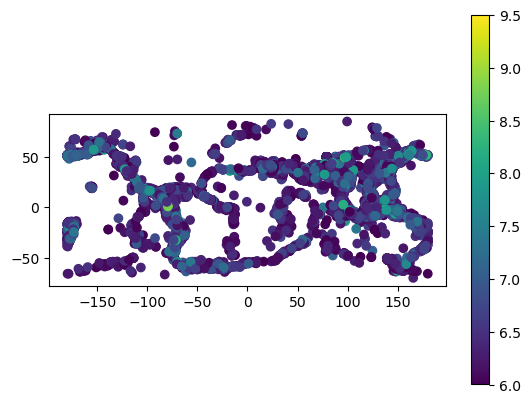

In [7]:
# plot the dataframe
earthquake_gdf.plot(column = "mag", legend=True);

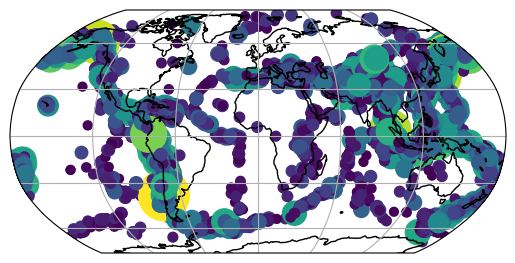

In [28]:
""" Plot the earthquakes by magnitude """
projection = cartopy.crs.Robinson()
fig, ax = plt.subplots(subplot_kw={"projection": projection})

# convert the geodataframe to the map projection
proj4_code = projection.proj4_init
earthquake_gdf_proj = earthquake_gdf.to_crs(proj4_code)

# plot the earthquakes
#earthquake_gdf_proj.plot(ax=ax)
size = np.exp(earthquake_gdf_proj['mag'])/10
transparency = size / size.max()
earthquake_gdf_proj.plot(ax=ax, column = 'mag', markersize=size)

ax.coastlines()
ax.gridlines()

plt.show()


## State boundaries

The next step involves filtering by state.  While technically we might be able to determine the location using the "place" column in the dataset, we can do better than that by using a shapefile to define the geospatial region we want to search and then using a point-in-polygon method to find earthquake points taht are within that region.

Note that this shapefile dataset was downloaded from  https://www.sciencebase.gov/catalog/item/52c78623e4b060b9ebca5be5 on Tuesday November 28, 2023 at 1:45pm Eastern.

In [29]:
""" Load the state boundary shapefile. """

state_shapefile_path = "https://github.com/taobrienlbl/advanced_earth_science_data_analysis/raw/09188e9e6a0cf230f8473c0ae95d2e1b9079df3a/lessons/13_geospatial_intro/data/tl_2012_us_state.zip"

states_gdf = gpd.read_file(state_shapefile_path)
states_gdf.head()

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,1,4,9,15,01779782,15,HI,Hawaii,00,G4000,A,1.663425e+10,1.167874e+10,+19.8097670,-155.5061027,2.419034e+06,3.268482e+10,"MULTIPOLYGON (((-17361760.204 2164544.588, -17..."
1,2,3,7,05,00068085,05,AR,Arkansas,00,G4000,A,1.347726e+11,2.959210e+09,+34.8955256,-092.4446262,2.656648e+06,2.053261e+11,"POLYGON ((-10515267.713 4101325.818, -10515269..."
2,3,4,8,35,00897535,35,NM,New Mexico,00,G4000,A,3.141611e+11,7.564385e+08,+34.4346843,-106.1316181,2.900368e+06,4.643927e+11,"POLYGON ((-12138963.727 4106855.17, -12138964...."
3,4,4,8,30,00767982,30,MT,Montana,00,G4000,A,3.769636e+11,3.868565e+09,+47.0511771,-109.6348174,4.607246e+06,8.201836e+11,"POLYGON ((-12727480.235 5886876.586, -12727567..."
4,5,1,2,36,01779796,36,NY,New York,00,G4000,A,1.220579e+11,1.923885e+10,+42.9133974,-075.5962723,3.212630e+06,2.637702e+11,"MULTIPOLYGON (((-8866092.533 5160809.769, -886..."


Since this is a dataframe, we can use pandas features to select rows.  I'm going to pull the row where the "STUSPS" column is "CA".

<Axes: >

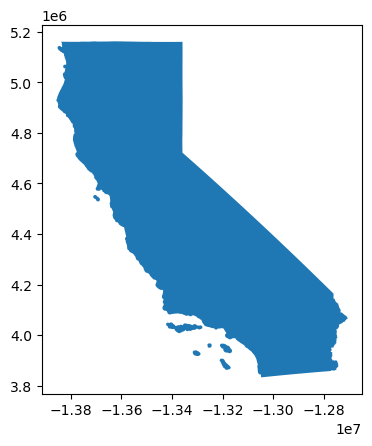

In [13]:
""" Extract the CA row. """
ca_gdf = states_gdf[states_gdf['STUSPS'] == 'CA']
ca_gdf.plot()

This particular shapefile seems to include coastal waters that are also part of the state (note how the islands look like dots).  That might not be great for some analyses, but for our purposes, that's just fine.

<Axes: >

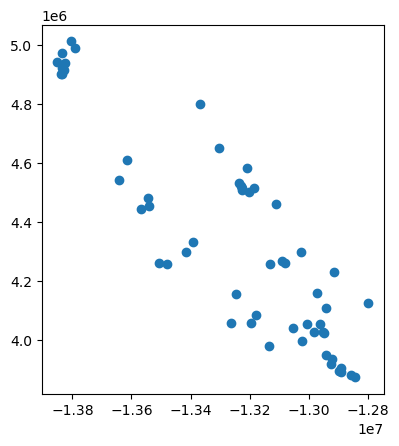

In [14]:
""" Use the CA boundary to clip the earthquakes. """

# convert the earthquake data to the CA projection
earthquake_gdf_ca = earthquake_gdf.to_crs(ca_gdf.crs)

# extract only the earthquakes within CA
earthquake_gdf_ca_clipped = gpd.clip(earthquake_gdf_ca, ca_gdf)

earthquake_gdf_ca_clipped.plot()



In [15]:
print(earthquake_gdf_ca )

                           time  latitude  longitude    depth   mag magType  \
0      2023-09-21T21:11:49.950Z  -14.0039   167.1898  188.419  6.10     mww   
1      2023-09-20T14:45:58.609Z   -4.5826  -105.6493   10.000  6.00     mww   
2      2023-09-18T13:21:23.790Z   26.4336   125.3032  183.483  6.30     mww   
3      2023-09-13T11:49:15.926Z  -36.2201   -97.9378   10.000  6.10     mww   
4      2023-09-12T11:03:18.873Z   19.2687   121.2178   41.281  6.30     mww   
...                         ...       ...        ...      ...   ...     ...   
13922  1902-01-01T05:20:30.000Z   52.3800  -167.4500      NaN  7.00      ms   
13923  1901-12-31T09:02:30.000Z   51.4500  -171.0200      NaN  7.10      ms   
13924  1901-12-30T22:34:00.000Z   52.0000  -160.0000      NaN  7.00      ms   
13925  1901-03-03T07:45:00.000Z   36.0000  -120.5000      NaN  6.40      ms   
13926  1900-10-09T12:25:00.000Z   57.0900  -153.4800      NaN  7.86      mw   

         nst    gap    dmin   rms  ...             

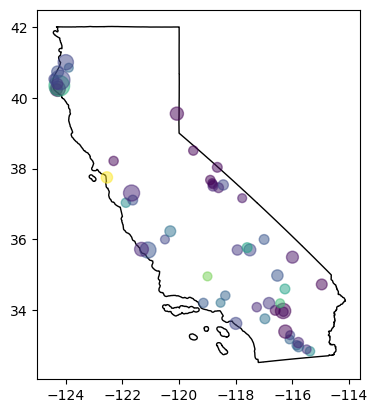

In [34]:
""" Use the CA boundary to clip the earthquakes. """

# convert the CA boundary to the projection of the earthquake data set
ca_gdf_proj = ca_gdf.to_crs(earthquake_gdf.crs)

#extract only the earthquakes within CA
earthquake_gdf_clipped = gpd.clip(earthquake_gdf, ca_gdf_proj)

# plot the boundary and the clipped earthquakes
fig, ax = plt.subplots()
ca_gdf_proj.plot(ax=ax, facecolor="none", edgecolor="black")

earthquake_gdf_clipped.plot(
    ax = ax, 
    column="mag",
    markersize = np.exp(earthquake_gdf_proj.mag)/10,
    alpha=0.5,
    )



# show the plot
plt.show()





What if we want earthquakes near CA: e.g., within 100 km?  We can inflate (*buffer*) the shapefile boundary to accomplish this.

Note, however, that the shapefile uses a degree-based coordinate system, so we'll *buffer* by degrees, using the fact that 1 degree is approximately 100 km.

<Axes: >

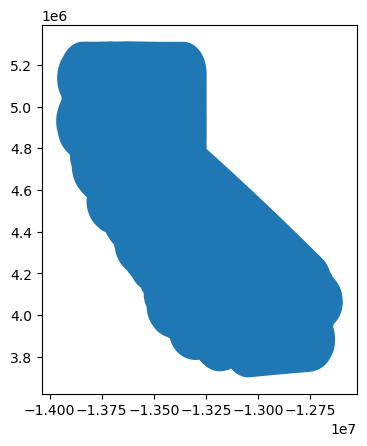

In [17]:
""" Inflate the CA shapefile boundary. """
# convert the CA geodataframe to PlateCarree projection
projection = cartopy.crs.PlateCarree()
proj4_code = projection.proj4_init

ca_gdf_pc = ca_gdf.to_crs(proj4_code)
ca_gdf_inflated = ca_gdf_pc.buffer(1.0) # buffer by 1 degree

# convert back to original projection
ca_gdf_inflated = ca_gdf_inflated.to_crs(ca_gdf.crs)

ca_gdf_inflated.plot()

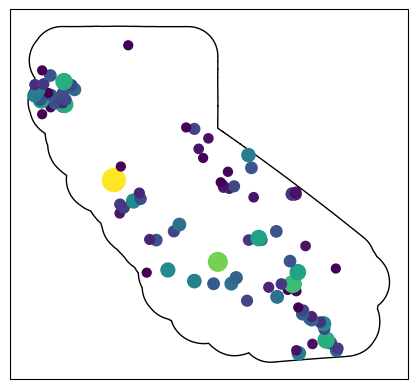

In [19]:
""" Save the inflated boundary to a shapefile for later use. """
# convert the earthquake data to the CA projection
earthquake_gdf_ca = earthquake_gdf.to_crs(ca_gdf_inflated.crs)

# extract only the earthquakes within CA
earthquake_gdf_ca_clipped = gpd.clip(earthquake_gdf_ca, ca_gdf_inflated)

# earthquake_gdf_ca_clipped.plot()

# plot the CA earthquakes
projection = cartopy.crs.PlateCarree()
fig, ax = plt.subplots(subplot_kw={"projection": projection})

# converrt the CA geodataframe to te map projection
proj4_code = projection.proj4_init
ca_gdf_inflated_proj = ca_gdf_inflated.to_crs(proj4_code)

# convert the earth
earthquake_gdf_ca_clipped_proj = earthquake_gdf_ca_clipped.to_crs(proj4_code)

# plot the CA boundary 
ca_gdf_inflated_proj.plot(ax=ax, edgecolor='black', facecolor='none')

size = np.exp(earthquake_gdf_ca_clipped_proj['mag'])/10
earthquake_gdf_ca_clipped_proj.plot(ax=ax, column = 'mag', markersize=size)

plt.show()

In [22]:
""" Save the inflated coundary to a shapefile for later use. """
ca_gdf_inflated.to_file("ca_state_boundary_infrated.shp.zip", driver="ESRI Shapefile")


In [23]:
""" Save the clipped earthquakes for later use. """
earthquake_gdf_ca_clipped.to_file("earthquake_gdf_ca_clipped.shp.zip", driver="ESRI Shapefile")

/tmp/ipykernel_1145443/1550297923.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  earthquake_gdf_ca_clipped.to_file("earthquake_gdf_ca_clipped.shp.zip", driver="ESRI Shapefile")
/N/slate/raquin/conda_envs/easg690/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'horizontalError' to 'horizontal'
  ogr_write(
/N/slate/raquin/conda_envs/easg690/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'locationSource' to 'locationSo'
  ogr_write(
